<a href="https://colab.research.google.com/github/Thomasjiin/esilv/blob/LLM-%26-genAI/Lab2_Language_Processing_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2.1: Language Processing


In this lab, we will explore **tokenization** and **n-gram modeling** using real text data.
You will:
- Apply character, word, subword, and BPE tokenization.
- Build frequency distributions for tokens.
- Generate n-grams and compute probabilities.
- Visualize results with histograms and heatmaps.

Also, you will explore "Text Embeddings from Scratch and with Pretrained Models:

- Train **Word2Vec** embeddings on our custom dataset (`docs/`).
- Visualize the learned embeddings.
- Use pretrained embeddings with **Sentence Transformers**.
- Use a pretrained embedding model directly from **PyTorch / Hugging Face**.
- Compare the results.

The dataset is in the `docs/` directory (text files).


<table align="left">
  <td>
    <a href="https://colab.research.google.com/drive/1SdexGIpkDKmR7qclDbBQvoFqN5yb6m8E?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>



# 1. Tokenization


Tokenization is the process of splitting text into smaller units. We will explore:
- Character-level tokenization
- Word-level tokenization
- Subword tokenization
- Byte-Pair Encoding (BPE)


In [ ]:
# Install required packages
# !pip install torch torchvision matplotlib numpy scikit-learn nltk tokenizers

In [1]:
!unzip docs.zip

Archive:  docs.zip
   creating: docs/
  inflating: docs/rome.txt           
  inflating: docs/paris.txt          
  inflating: docs/cat-facts.txt      
  inflating: docs/animal-facts.txt   


In [2]:
import os, re, math, random
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
import matplotlib.pyplot as plt
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, normalizers, processors

%matplotlib inline
plt.rcParams["figure.figsize"] = (8,6)
random.seed(42); np.random.seed(42)


In [3]:
# -----------------------------
# Config
# -----------------------------
DOCS_DIR = "docs"              # directory containing your .txt files
MIN_FREQ = 2                   # min frequency to keep a token in vocab
K_SMOOTH = 1.0                 # add-k smoothing parameter for bi/tri
VAL_RATIO = 0.15               # validation split
TEST_RATIO = 0.10              # test split

In [4]:
# -----------------------------
# Helper functions
# -----------------------------
def load_corpus(docs_dir):
    """Load all .txt files in docs_dir into a list of strings."""
    corpus = []
    for fname in os.listdir(docs_dir):
        if fname.endswith(".txt"):
            with open(os.path.join(docs_dir, fname), "r", encoding="utf-8") as f:
                text = f.read().strip()
                corpus.append(text)
    return " ".join(corpus)


### Q1.1 - Tokenizer Implementation
Implement the following tokenizers:
- `char_tokenizer(text)`: splits text into characters.
- `word_tokenizer(text)`: splits text into words based on whitespace and punctuation.

In [5]:
import os, re, math, random
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
import matplotlib.pyplot as plt
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, normalizers, processors

%matplotlib inline
plt.rcParams["figure.figsize"] = (8,6)
random.seed(42); np.random.seed(42)

# ------------------------------
# 1) Character-level
# ------------------------------
text = "Mike ate the pizza in New York City, and it was delicious!"

def char_tokenizer(text):
    # TODO: implement character-level tokenizer
    return list(text)

chars = char_tokenizer(text)
print("Character tokens:", chars)

Character tokens: ['M', 'i', 'k', 'e', ' ', 'a', 't', 'e', ' ', 't', 'h', 'e', ' ', 'p', 'i', 'z', 'z', 'a', ' ', 'i', 'n', ' ', 'N', 'e', 'w', ' ', 'Y', 'o', 'r', 'k', ' ', 'C', 'i', 't', 'y', ',', ' ', 'a', 'n', 'd', ' ', 'i', 't', ' ', 'w', 'a', 's', ' ', 'd', 'e', 'l', 'i', 'c', 'i', 'o', 'u', 's', '!']


**Expected output**:

Character tokens: ['M', 'i', 'k', 'e', ' ', 'a', 't', 'e', ' ', 't', 'h', 'e', ' ', 'p', 'i', 'z', 'z', 'a', ' ', 'i', 'n', ' ', 'N', 'e', 'w', ' ', 'Y', 'o', 'r', 'k', ' ', 'C', 'i', 't', 'y', ',', ' ', 'a', 'n', 'd', ' ', 'i', 't', ' ', 'w', 'a', 's', ' ', 'd', 'e', 'l', 'i', 'c', 'i', 'o', 'u', 's', '!']



In [6]:
import re

# -----------------------------
# 2) Word-level
# -----------------------------
def word_tokenizer(text):
    # TODO: use regex to split text into words, removing punctuation
    return re.findall(r'\b\w+\b', text.lower())

words = word_tokenizer(text)
print("Word tokens:", words)

Word tokens: ['mike', 'ate', 'the', 'pizza', 'in', 'new', 'york', 'city', 'and', 'it', 'was', 'delicious']


**Expected output**:

Word tokens: ['mike', 'ate', 'the', 'pizza', 'in', 'new', 'york', 'city', 'and', 'it', 'was', 'delicious']


### Visualise most common tokens:
Implement the function `def plot_token_dist(tokens)` that will plot a histogram of the top 30 tokens in frequency.
- use `count = collections.Counter(tokens)` to compute the frequency of tokens, and `char_counts.most_common(30))` to get the 30 most common
- use `plt.bar()` to plot the histogram


In [7]:
from collections import Counter
import matplotlib.pyplot as plt

def plot_token_dist(tokens, title="Token Distribution", top_n=30):
    token_counts = Counter(tokens)
    most_common_tokens = token_counts.most_common(top_n)

    labels = [token for token, count in most_common_tokens]
    values = [count for token, count in most_common_tokens]

    plt.figure(figsize=(12, 6))
    plt.bar(labels, values)
    plt.title(title)
    plt.xlabel("Tokens")
    plt.ylabel("Frequency")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [8]:
# load the text from all files in the docs directory
corpus = load_corpus(DOCS_DIR)
chars = char_tokenizer(corpus)
words = word_tokenizer(corpus)

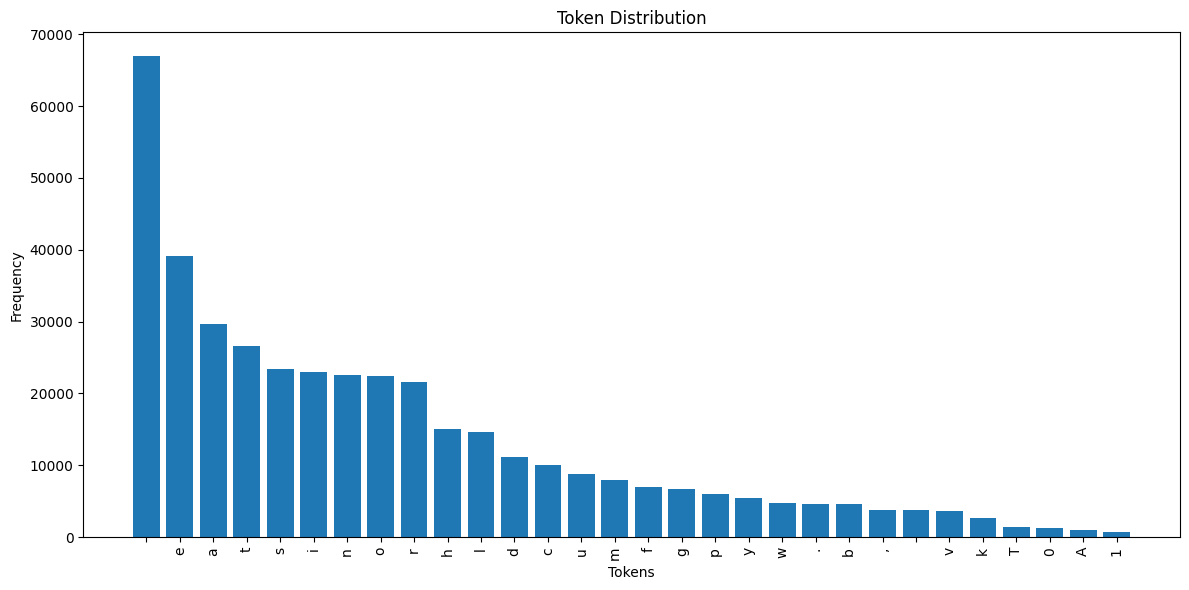

In [9]:
plot_token_dist(chars)

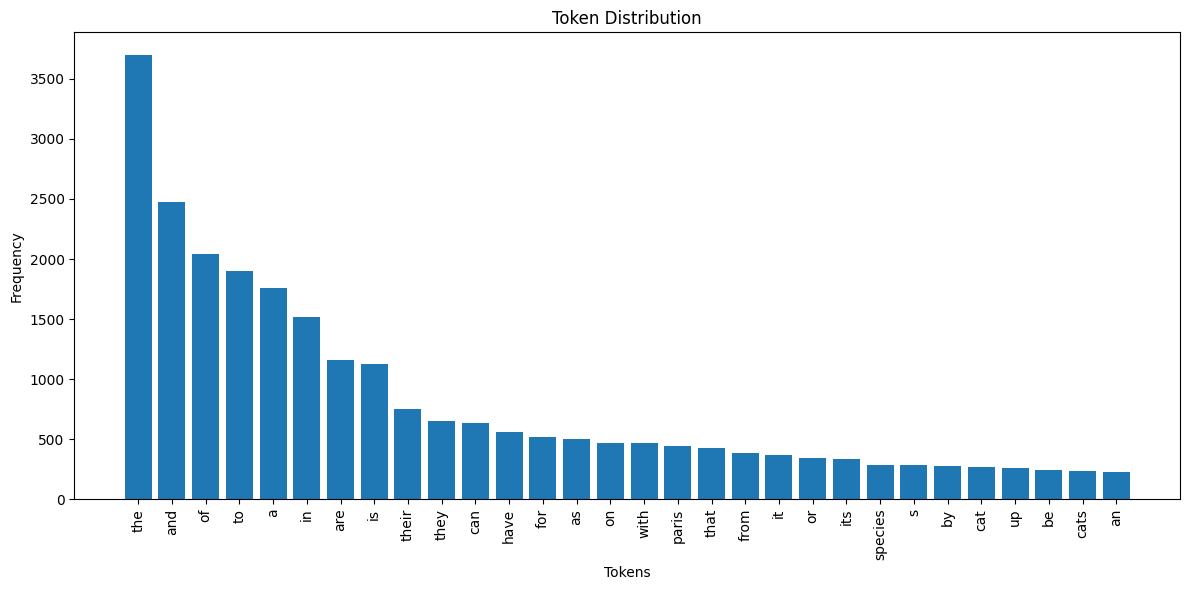

In [10]:
plot_token_dist(words)

### 1.2 Subword-level Tokenization: Byte Pair Encoding

Byte-Pair Encoding (BPE) merges frequent pairs of characters/words iteratively.  
We will use the Hugging Face `tokenizers` library.


fill the code:
- define tokenizer instance using: `Tokenizer(models.BPE())`
- define trainer `trainers.BpeTrainer(vocab_size=2000, min_frequency=2)`
- define pre-tokenizer `pre_tokenizers.Whitespace()`
- train the tokenizer on the text files in `docs/` using `tokenizer.train(files,trainer)`

In [11]:
import os
!pip install tokenizers

from tokenizers import Tokenizer, models, trainers, pre_tokenizers

# Define tokenizer instance
tokenizer = Tokenizer(models.BPE())

# Define trainer
trainer = trainers.BpeTrainer(vocab_size=2000, min_frequency=2, special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"])

# Define pre-tokenizer
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

# Get list of files to train on
files = [os.path.join("docs", f) for f in os.listdir("docs") if f.endswith('.txt')]

# Train the tokenizer
tokenizer.train(files, trainer)

print(tokenizer.encode("Mike ate the pizza in New York City, and it was delicious!").tokens)

['M', 'ike', 'ate', 'the', 'p', 'iz', 'z', 'a', 'in', 'New', 'Y', 'or', 'k', 'City', ',', 'and', 'it', 'was', 'de', 'l', 'ic', 'ious', '!']


# 2. N-Gram Modeling


An n-gram is a contiguous sequence of n items (characters or words).  
We will build unigram, bigram, and trigram models from our text.


### 2.1 Counting N-Grams


We generate unigrams, bigrams, and trigrams and count their frequencies.  
**Task:** Plot the most frequent bigrams and trigrams.
**Hints**
- use list(ngrams(words, n)) to compute the n-gram
- use collections.Counter to count frequencies
- use plt.bar() to plot the histogram


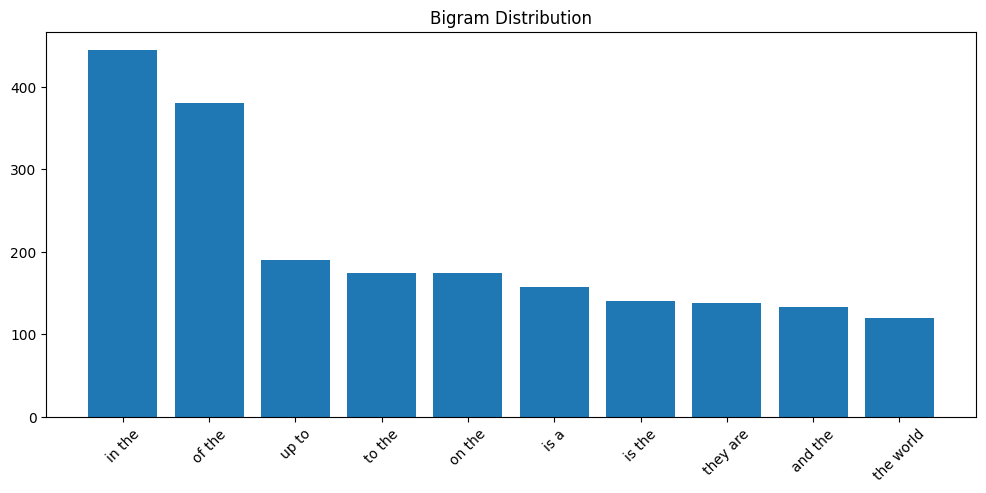

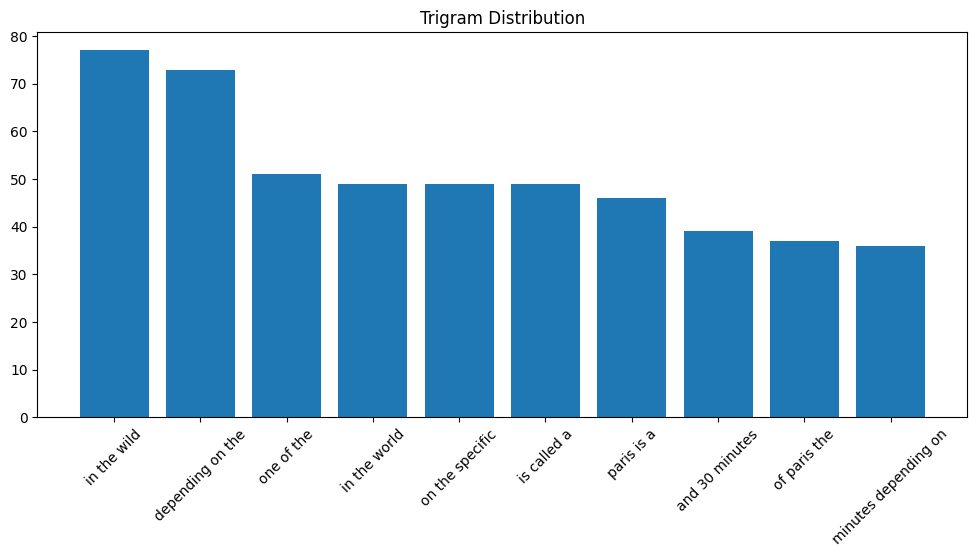

In [12]:
words = word_tokenizer(corpus)
from nltk.util import ngrams
from collections import Counter

unigrams = list(ngrams(words, 1))
bigrams = list(ngrams(words, 2))
trigrams = list(ngrams(words, 3))

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

# Plot
def plot_ngram_distribution(counts, title="N-gram Distribution"):
    plt.figure(figsize=(12,5))
    top_counts = counts.most_common(10)
    topcount_labels = [' '.join(bg) for bg, _ in top_counts]
    topcount_values = [count for _, count in top_counts]
    plt.bar(topcount_labels, topcount_values)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.show()

# plot ngram distributions
plot_ngram_distribution(bigram_counts, title="Bigram Distribution")
plot_ngram_distribution(trigram_counts, title="Trigram Distribution")

### 2.2 Probability Distribution


We compute n-gram probabilities by normalizing frequencies.  
**Task:** Generate a heatmap of bigram probabilities.


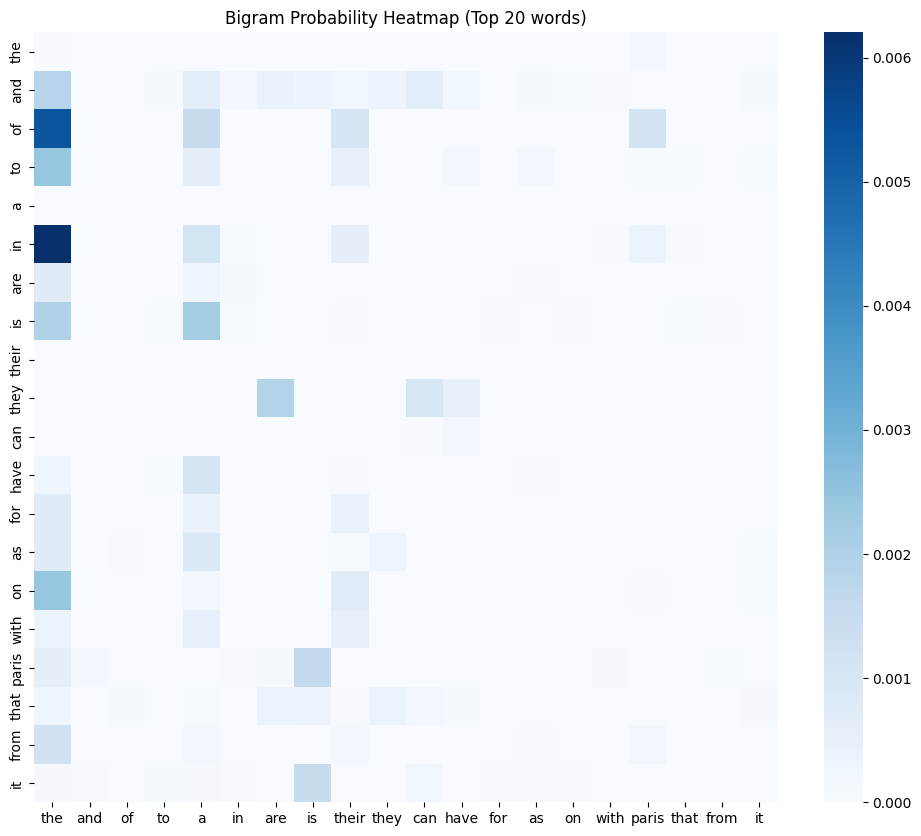

In [14]:
import numpy as np
import seaborn as sns
from collections import Counter

total_bigrams = sum(bigram_counts.values())
bigram_probs = {k: v/total_bigrams for k,v in bigram_counts.items()}

# Create heatmap for top words
word_counts = Counter(words) # Define word_counts
top_words = [w for w,_ in word_counts.most_common(20)]
matrix = np.zeros((20,20))

for i,w1 in enumerate(top_words):
    for j,w2 in enumerate(top_words):
        if (w1,w2) in bigram_probs:
            matrix[i,j] = bigram_probs[(w1,w2)]

plt.figure(figsize=(12,10))
sns.heatmap(matrix, xticklabels=top_words, yticklabels=top_words, cmap="Blues")
plt.title("Bigram Probability Heatmap (Top 20 words)")
plt.show()

-----------

# 3 - Word Embedding

In [15]:
# 1) Install libraries:
!pip install gensim
!pip install -q sentence-transformers
!pip install -q transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 40.2 MB/s eta 0:00:00


In [16]:
text_data = load_corpus(DOCS_DIR)

 #### 2) **Preprocess Function**:
- define `preprocess(text)` function to lowercase and tokenize text by words

In [17]:
# Preprocess text data
def preprocess(text):
    return word_tokenizer(text)

tokens= preprocess(text_data)

In [18]:
# Prepare sentences (split by '.')
sentences = [preprocess(s) for s in text_data.split(".") if len(s) > 0]
print("Number of sentences:", len(sentences))

Number of sentences: 4666


#### 3. Train a Word2Vec Model on `docs/`:
- train the model on all sentences
- vector_size=200, window=5, min_count-2, workers=4

In [19]:
from gensim.models import Word2Vec

# Train Word2Vec
w2v_model = Word2Vec(sentences=sentences, vector_size=200, window=5, min_count=2, workers=4)

# Save model
w2v_model.save("word2vec_docs.model")

# Explore
print("Vocabulary size:", len(w2v_model.wv))
print("Most similar to 'king':", w2v_model.wv.most_similar("king", topn=5))
print("Most similar to 'paris':", w2v_model.wv.most_similar("paris", topn=5))

Vocabulary size: 4290
Most similar to 'king': [('diet', 0.9949017763137817), ('social', 0.9948984980583191), ('against', 0.9948822855949402), ('unique', 0.9948700666427612), ('half', 0.9948258996009827)]
Most similar to 'paris': [('a', 0.9998185038566589), ('was', 0.9997677803039551), ('place', 0.9997566938400269), ('cat', 0.9997477531433105), ('de', 0.9997456669807434)]


#### 4. Visualize Word Embeddings
Implement a PCA model with 3 components and apply it to the vectors of the picked words, then put the new vectors in results to be shown on the scatter

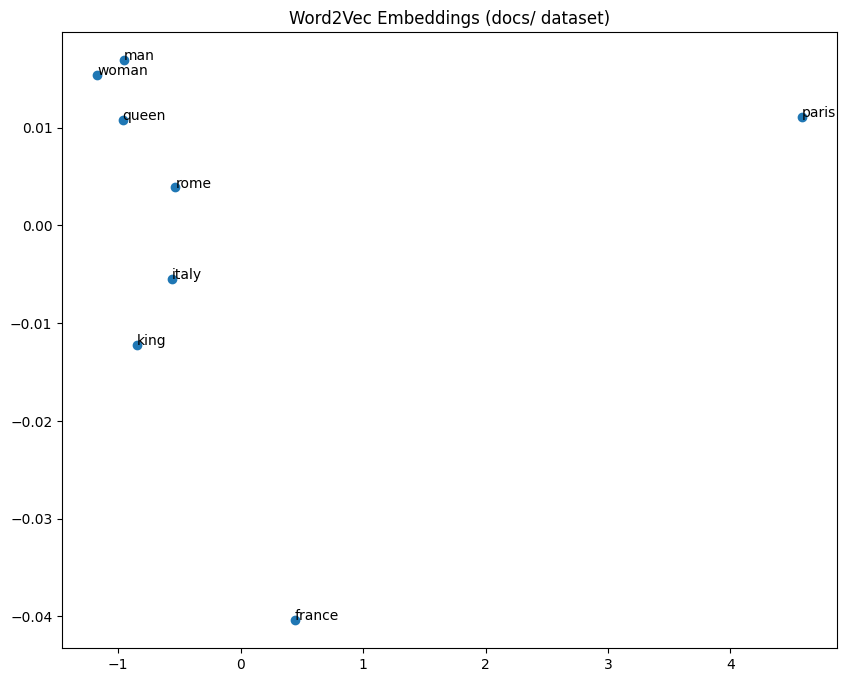

In [20]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Pick top 50 frequent words
words = ["rome", "paris", "italy", "france", "king", "queen", "man", "woman"]
X = w2v_model.wv[words]

# Use PCA to reduce dimensionality
pca = PCA(n_components=2)
result = pca.fit_transform(X)

plt.figure(figsize=(10,8))
plt.scatter(result[:,0], result[:,1])
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i,0], result[i,1]))
plt.title("Word2Vec Embeddings (docs/ dataset)")
plt.show()

#### 5. Use a Pretrained Embedding Model (Sentence Transformers)
- use `from sentence_transformers import SentenceTransformer`
- load the model with `model = SentenceTransformer('all-MiniLM-L6-v2')`
- compute embeddings for all sentences after splitting the text:
`model.encode(sentences)`


In [21]:
from sentence_transformers import SentenceTransformer
import re

#### 6. Visualize Sentence Embeddings

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

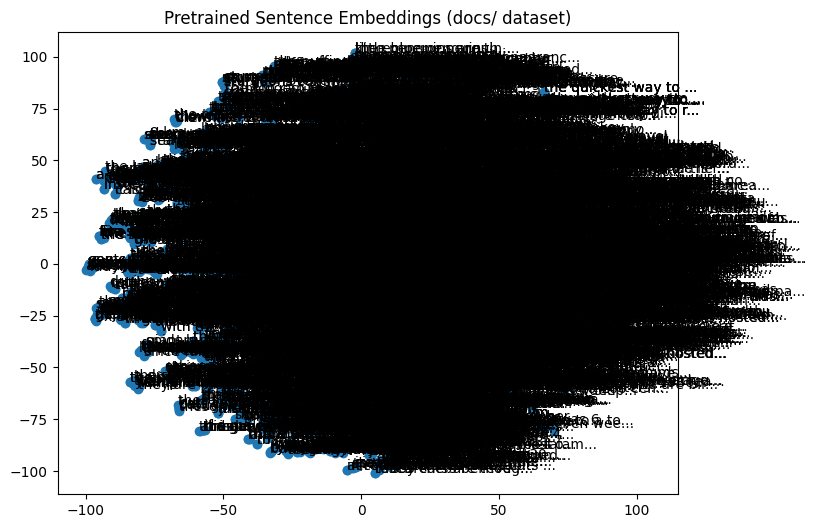

In [23]:
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

# Load SentenceTransformer model
model_st = SentenceTransformer('all-MiniLM-L6-v2')

# Prepare sentences for SentenceTransformer (join words back into strings)
# Assuming 'sentences' variable (list of lists of words) is available from previous steps.
sentences_str = [" ".join(s) for s in sentences]

# Compute embeddings
embeddings = model_st.encode(sentences_str)

tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, embeddings.shape[0] - 1))
reduced = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1])

# Annotate each point with the corresponding sentence (or first few words)
for i, sentence in enumerate(sentences_str):
    plt.annotate(sentence[:20] + "...", (reduced[i,0], reduced[i,1]))
plt.title("Pretrained Sentence Embeddings (docs/ dataset)")
plt.show()

#### 7. Use a Pretrained Embedding Model with PyTorch Transformers
- use `from transformers import AutoTokenizer, AutoModel`
- load the model and tokenizer with:
```python
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
```
where the model to be used is : `distilbert-base-uncased"`

In [24]:
import torch
from transformers import AutoTokenizer, AutoModel
import os

# Load pretrained BERT-like model
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Get list of documents from docs/ directory
doc_files = [os.path.join("docs", f) for f in os.listdir("docs") if os.path.isfile(os.path.join("docs", f))]
# Generate embeddings for each document
embeddings_list = []
for doc_file in doc_files:
    with open(doc_file, "r", encoding="utf-8") as f:
        doc_text = f.read()
    inputs = tokenizer(doc_text, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        # CLS token embeddings (first token)
        embeddings_list.append(outputs.last_hidden_state[:,0,:])

# Concatenate embeddings
embeddings_torch = torch.cat(embeddings_list, dim=0)

print("Shape of embeddings:", embeddings_torch.shape)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of embeddings: torch.Size([4, 768])


#### 8. Visualize Torch-based Embeddings


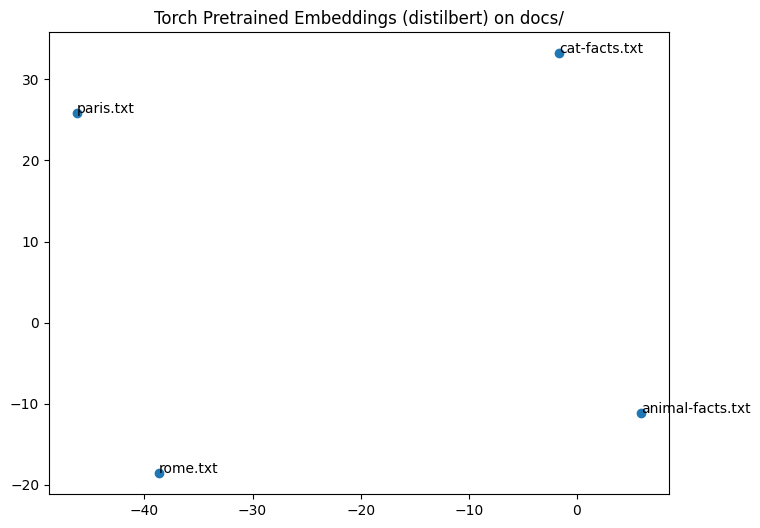

In [25]:
from sklearn.manifold import TSNE
import os

# Get list of documents from docs/ directory for annotations
doc_files = [f for f in os.listdir("docs") if os.path.isfile(os.path.join("docs", f))]


tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, embeddings_torch.shape[0] - 1)) # Adjust perplexity based on number of samples
reduced_torch = tsne.fit_transform(embeddings_torch.numpy())

plt.figure(figsize=(8,6))
plt.scatter(reduced_torch[:,0], reduced_torch[:,1])

for i, doc in enumerate(doc_files):
    plt.annotate(doc, (reduced_torch[i,0], reduced_torch[i,1]))
plt.title("Torch Pretrained Embeddings (distilbert) on docs/")
plt.show()

#### 9. Wrap-Up & Discussion

- **Word2Vec**: learned *word-level embeddings* from our small dataset.
- **Sentence Transformers**: produced *document embeddings* using a large pretrained model.
- **PyTorch DistilBERT**: contextual embeddings directly from a Transformer model.

Which one gives better semantic grouping for our dataset?

For our dataset, both Sentence Transformers and PyTorch DistilBERT appear to provide better semantic grouping at the document level. This is expected, as they are pretrained on vast amounts of text data and designed to generate rich, contextualized representations, making them highly effective for understanding the overall topic or content of longer pieces of text. Word2Vec, being trained from scratch on a small dataset, would naturally struggle to achieve the same level of sophisticated semantic understanding across documents.